# Research Question 3: Are there concurrent changes in moth counts across sites? What drives them?

## Mounting Drive and Importing Libraries

In [1]:
# mounting drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import statsmodels.formula.api as smf

## Loading the Dataset

In [3]:
# load the dataset
path = "/content/drive/MyDrive/Colab Notebooks/SCC 450 - Group Project/Week 10/Data/DATA_CLEAN.csv"
df = pd.read_csv(path, parse_dates = ["SAMPLE_DATE", "FROMDATE", "SDATE"])
df

/tmp/ipython-input-240396561.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates = ["SAMPLE_DATE", "FROMDATE", "SDATE"])


,SITECODE,LCODE,SAMPLE_DATE,FIELDNAME,VALUE,FROMDATE,SPERIOD_D,YEAR,WEEK_NEW,98_PERCENTILE,...,SDATE,DRYTMP,NETRAD,SOLAR,STMP10,STMP30,SURWET,WDIR,WSPEED,RAIN
0,T01,1,1993-01-03,XX,0,1993-01-02,1,1993,1,0.00,...,1993-01-02,-2.345833,4.583333,10.500000,0.429167,2.958333,5.875000,0.000000,0.000000,0.00
1,T08,1,1993-01-03,XX,0,1993-01-02,1,1993,1,0.00,...,1993-01-02,-2.733333,3.333333,12.000000,4.155075,4.375149,39.838371,143.916667,0.970833,0.00
2,T08,1,1993-01-04,XX,0,1993-01-03,1,1993,1,0.00,...,1993-01-03,-2.950000,13.083333,50.666667,4.155075,4.375149,39.838371,141.375000,2.775000,0.20
3,T01,1,1993-01-04,XX,0,1993-01-03,1,1993,1,0.00,...,1993-01-03,-1.541667,17.708333,45.458333,0.154167,2.854167,20.666667,77.250000,1.000000,0.00
4,T08,1,1993-01-05,XX,0,1993-01-04,1,1993,1,0.00,...,1993-01-04,2.283333,3.791667,12.000000,4.155075,4.375149,39.838371,188.041667,2.975000,1.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247178,T08,1,2015-11-28,828,1,2015-11-27,1,2015,47,9.00,...,2015-11-27,9.033333,-6.625000,25.041667,9.054167,8.958333,56.958333,236.583333,3.416667,3.00
247179,T08,1,2015-12-07,277,1,2015-12-06,1,2015,49,3.86,...,2015-12-06,11.904167,-7.250000,15.083333,9.575000,9.587500,23.166667,217.875000,4.337500,0.20
247180,T09,1,2015-12-13,590,1,2015-12-12,1,2015,50,6.00,...,2015-12-12,9.030000,-2.520833,12.091667,5.961648,9.437500,24.514915,241.525000,1.582083,0.40
247181,T06,2,2015-12-17,591,1,2015-12-16,1,2015,50,2.00,...,2015-12-16,12.598750,-11.325000,13.979167,10.077917,9.369167,21.650000,222.041667,3.045417,2.21


## Creating a Table of Mean Moth Counts at Each SITECODE over the Years

In [4]:
# selecting unique samples
unique_samples = df[["SITECODE", "YEAR", "LCODE", "SAMPLE_DATE", "VALUE"]].drop_duplicates()

# calculating mean for every site across years
site_moth_mean = unique_samples.groupby(["YEAR", "SITECODE"])["VALUE"].mean().unstack()
site_moth_mean

# this is due to preserve that number of entries is not the same

SITECODE,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T12
YEAR,,,,,,,,,,,
1993,1.808950,NaN,0.319149,0.921922,NaN,2.780822,0.939394,1.083130,NaN,NaN,NaN
1994,2.169628,2.774194,0.632959,0.802721,NaN,3.532864,1.922290,1.073227,1.614286,0.560976,NaN
1995,3.074753,2.221095,1.834437,1.295154,3.708779,3.447307,2.202729,1.597077,1.967626,3.690909,NaN
1996,3.646707,2.033465,NaN,1.730382,2.669742,4.134673,2.507666,1.552063,1.904847,NaN,NaN
1997,2.729730,1.264484,NaN,1.488273,1.658824,2.982955,1.723112,1.687627,1.701031,3.503311,NaN
1998,2.295918,0.903315,NaN,0.704715,1.706402,2.183432,1.573248,1.126464,1.702259,0.091954,NaN
1999,1.570213,0.974063,NaN,0.674129,1.610753,3.078365,1.362720,1.124138,1.680639,NaN,NaN
2000,2.980088,2.456081,NaN,2.030172,0.847458,3.146341,2.067416,2.067340,2.220386,NaN,NaN
2001,2.104283,1.733656,0.179487,1.385714,1.640625,3.456480,1.730159,1.090261,1.570248,NaN,5.571429


## Plot: Site Correlation Heatmap

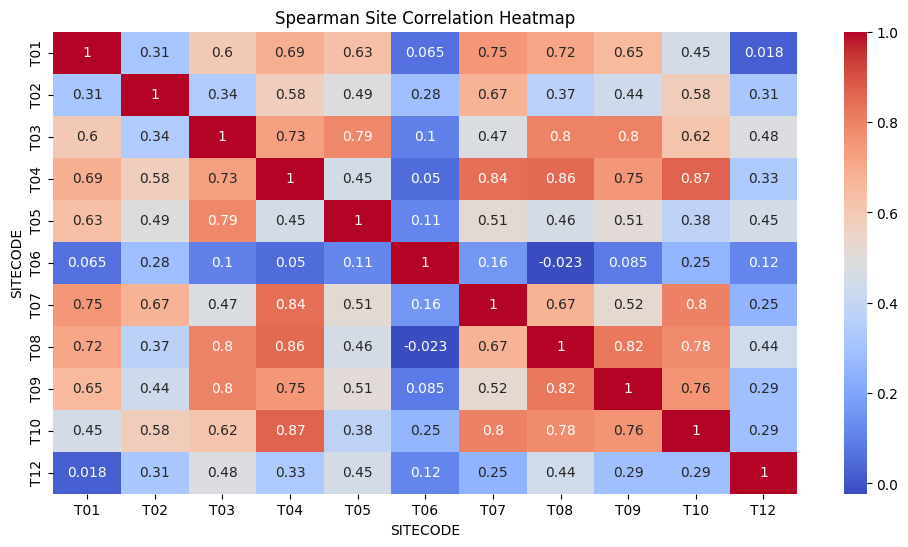

In [5]:
# calculating correlation - using spearman correlation
site_correlation = site_moth_mean.corr(method = "spearman")

# plotting heatmap
plt.figure(figsize = (12, 6))
sns.heatmap(site_correlation, cmap = "coolwarm", annot = True)
plt.title("Spearman Site Correlation Heatmap")
plt.show()

## Using Clustering to Group Sites that Correlate With Each Other

### Calculating Ideal Number of Clusters

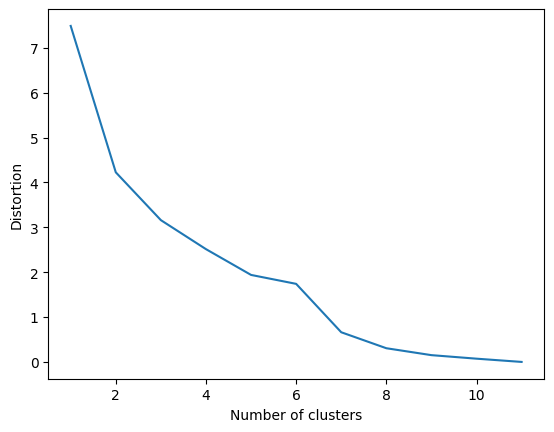

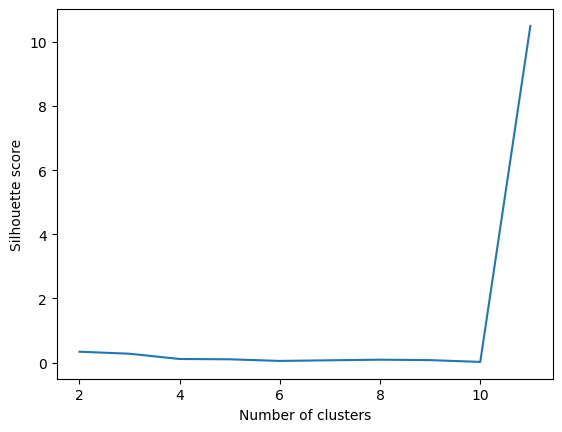

Optimal number of clusters: 11


In [6]:
# determining optimal number of clusters - silhouette score and elbow method
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# max number of clusters
K = len(site_correlation.columns)

# initializing arrays for elbow method and silhouette_score
dist = np.empty(K, dtype = np.float64)
sil_score = np.empty(K, dtype = np.float64)

# calcualting scores for clusters 1 - 11:
for k in range(1, K + 1):
  kmeans = KMeans(n_clusters = k, random_state = 42)
  kmeans.fit(site_correlation)
  dist[k - 1] = kmeans.inertia_
  if k > 1 and k <= 10 :
    sil_score[k - 1] = silhouette_score(site_correlation, kmeans.labels_)

# plotting elbow method
plt.figure()
plt.plot(range(1, K + 1), dist)
plt.xlabel("Number of clusters")
plt.ylabel("Distortion")

# plotting silhouette score
plt.figure()
plt.plot(range(2, K + 1), sil_score[1:])
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")

# shhowing the plot
plt.show()

# printing ooptimal number of clusters
k = np.argmax(sil_score[1:]) + 2
print(f"Optimal number of clusters: {k}")

### Assigning Cluster Labels to each SITECODE

1    7
0    4
Name: count, dtype: int64


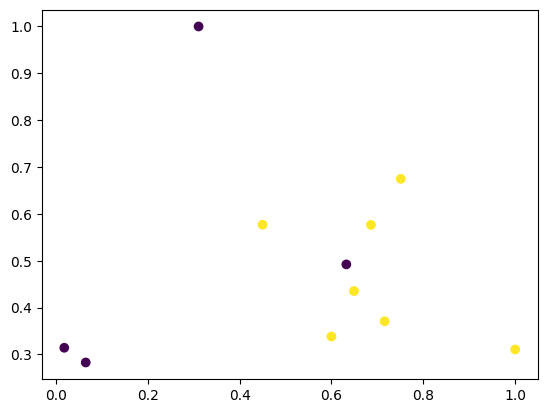

In [7]:
# assigning sites to clusters (number of clusters = 2)
kmeans = KMeans(n_clusters = 2, random_state = 42)
kmeans.fit(site_correlation)

# counting items per cluster
print(pd.Series(kmeans.labels_).value_counts())

# assigning each site a cluster
site_correlation["CLUSTER"] = kmeans.labels_

# plotting clusters
plt.scatter(site_correlation["T01"], site_correlation["T02"], c = site_correlation["CLUSTER"])

### Performing PCA and Plotting Clusters

Text(0.5, 1.0, 'Clustered Sites Based on Correlation')

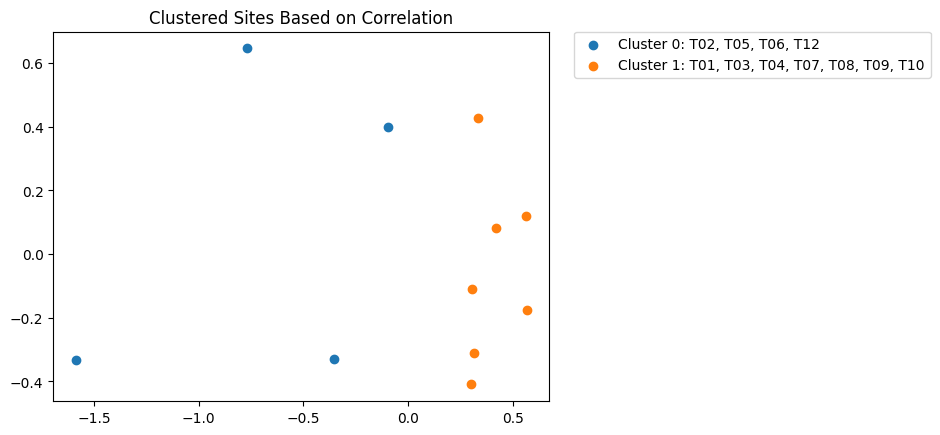

In [8]:
# running PCA to have only 2 dimensions to plot clusters
from sklearn.decomposition import PCA

# slicing the data that I want to be reduced
data = site_correlation.loc[:, :"T12"]
pca = PCA(n_components = 2) # 2 dimensions

# transforming the data to 2 dimensions
X = pca.fit_transform(data)
df_pca = pd.DataFrame(X, columns = ["x", "y"])

# adding columns
df_pca["CLUSTER"] =  site_correlation["CLUSTER"].values
df_pca["SITECODE"] = site_correlation.index.values

# creating a legend to see which sites are in which cluster + plotting the clusters with the customized legend
site_legend = df_pca.groupby("CLUSTER")["SITECODE"].apply(lambda x: ', '.join(x)).to_dict()
unique_clusters = np.sort(df_pca["CLUSTER"].unique())

for cluster_id in unique_clusters:
    cluster_df = df_pca[df_pca["CLUSTER"] == cluster_id]
    sites_string = site_legend[cluster_id]
    legend_label = f"Cluster {cluster_id}: {sites_string}"
    plt.scatter(cluster_df["x"], cluster_df["y"], label = legend_label)

# putting the legend out of the scatter plot
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left", borderaxespad = 0.) # legend outside of the plot (copied from a sample from matplotlib documentation website)
plt.title("Clustered Sites Based on Correlation")

## Cluster 0

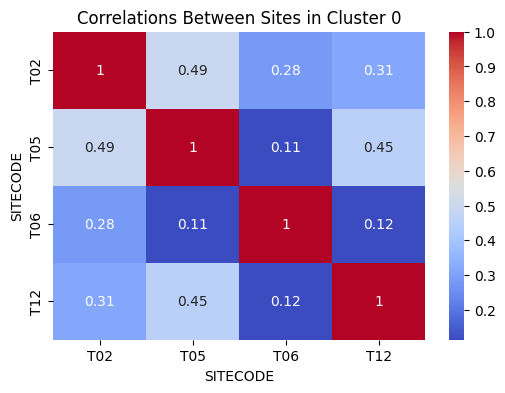

In [9]:
# extracting SITECODEs and their moth counts for each year
cluster_0 = site_correlation[site_correlation["CLUSTER"] == 0].index.values
cluster_0 = site_moth_mean.loc[:, cluster_0]
corr_cluster0 = cluster_0.corr(method = "spearman")

# plotting heatmap
plt.figure(figsize = (6, 4))
sns.heatmap(corr_cluster0, cmap = "coolwarm", annot = True)
plt.title("Correlations Between Sites in Cluster 0")
plt.show()

### Preparing Data for Regression

In [10]:
sites = ["T02", "T05", "T06", "T12"]

# aggregating moth data for cluster 0
unique_samples = df[["SITECODE", "YEAR", "LCODE", "SAMPLE_DATE", "VALUE"]].drop_duplicates()
moth_cluster0 = unique_samples[unique_samples["SITECODE"].isin(sites)]
moth_cluster0 = moth_cluster0.groupby(["YEAR", "SITECODE"])["VALUE"].mean().reset_index().sort_values(by = ["SITECODE", "YEAR"])
moth_cluster0.reset_index(drop = True, inplace = True)
moth_cluster0

# aggregating weather data
weather_vars = ['SITECODE', 'YEAR', 'DRYTMP', 'NETRAD', 'SOLAR', 'STMP10', 'STMP30', 'SURWET', 'WSPEED', 'RAIN'] # plus year
weather_cluster0 = df[df["SITECODE"].isin(sites)]
weather_cluster0 = weather_cluster0.loc[:, weather_vars]
weather_cluster0 = weather_cluster0.groupby(["SITECODE", "YEAR"]).agg(
    {
    "DRYTMP": "mean",
    "NETRAD": "mean",
    "SOLAR": "mean",
    "STMP10": "mean",
    "STMP30": "mean",
    "SURWET": "mean",
    "WSPEED": "mean",
    "RAIN": "sum"
}).reset_index()

# merging moth and weather data for cluster 0
cluster0_regression = pd.merge(moth_cluster0, weather_cluster0, on = ["SITECODE", "YEAR"], how = "inner")

# calculating log of VALUE for modeling
cluster0_regression["LOG_VALUE"] = np.log(cluster0_regression["VALUE"])

# ajdusting LOG_VALUE position
cluster0_regression = cluster0_regression.loc[:, ["YEAR", "SITECODE", "VALUE", "LOG_VALUE", "DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]]

 # applying robust scaling to weather variables
robust_scaler = RobustScaler()
cols = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]
for col in cols:
  robust_scaler = RobustScaler()
  cluster0_regression[col] = robust_scaler.fit_transform(cluster0_regression[[col]])

cluster0_regression

,YEAR,SITECODE,VALUE,LOG_VALUE,DRYTMP,NETRAD,SOLAR,STMP10,STMP30,SURWET,WSPEED,RAIN
0,1994,T02,2.774194,1.020360,-0.152413,-1.156325,-0.612662,-0.038328,-0.287483,0.954761,-0.270010,-1.325585
1,1995,T02,2.221095,0.798000,-0.055773,-1.576616,-0.046034,-0.052869,-0.331030,0.988002,-0.156176,-0.883554
2,1996,T02,2.033465,0.709741,-0.376439,-0.584912,-0.378508,-0.152664,-0.384865,-0.346010,-0.174655,-0.051211
3,1997,T02,1.264484,0.234664,-0.349493,-0.538919,-0.228078,0.033384,-0.331539,-0.287780,-0.390576,-0.480008
4,1998,T02,0.903315,-0.101684,-0.646631,-1.111170,-1.105548,-0.160432,-0.490579,0.556685,-0.084814,-0.243782
...,...,...,...,...,...,...,...,...,...,...,...,...
75,2011,T12,5.937984,1.781370,-1.282075,-1.034900,-0.610625,-0.756848,-0.993784,-0.229687,2.608645,3.390745
76,2012,T12,4.230769,1.442384,-2.404040,-1.916707,-1.637726,-1.684876,-1.873220,-0.020821,3.565373,-0.322400
77,2013,T12,4.235955,1.443609,-0.917719,-0.765841,-0.047185,-0.581345,-0.816146,-0.073065,3.178688,0.711100
78,2014,T12,5.201754,1.648996,-1.151866,-0.603821,-0.121392,-0.693562,-0.924321,-0.029424,2.129172,1.720157


### Regression for Cluster 0

#### Correlation Heatmap of Weather Variables for Cluster 0

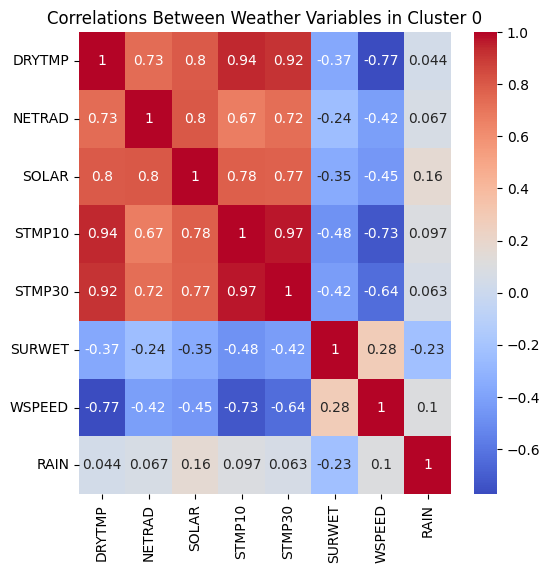

In [11]:
# checking for correlation between weather variables
weather_vars = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]

# calculating the correlation matrix
weather_corr = cluster0_regression[weather_vars].corr()

## plotting heatmap
plt.figure(figsize = (6, 6))
sns.heatmap(weather_corr, cmap = "coolwarm", annot = True)
plt.title("Correlations Between Weather Variables in Cluster 0")
plt.show()

# THRESHOLD: 0.6
# DRYTMP, NETRAD, SOLAR, STMP10, and STMP30 have high correlations between each other

#### Regression 1: DRYTMP, SURWET, WSPEED, RAIN

In [12]:
# defining formula
formula_1 = "LOG_VALUE ~ DRYTMP + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_1 = smf.ols(formula = formula_1, data = cluster0_regression).fit()

# printing results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                     17.22
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           3.54e-13
Time:                        14:07:34   Log-Likelihood:                -16.564
No. Observations:                  80   AIC:                             49.13
Df Residuals:                      72   BIC:                             68.18
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9038      0

In [13]:
# conclusions:

# R-squared: 0.626 - this model explains 62.6% of variation in the moth data

# DRYTMP (Dry bulb temperature - average): coeff = 0.7093, P>|t| = 0.000 - the strongest positive driver of moth abundance in this model
# WSPEED (Wind speed - average): coeff =  0.2438, P>|t| = 0.021 - this suggest moderate positive driver of moth abundance in this model !!!!!!!!!!!!!!!!!!

# RAIN and SURWET - low/moderate positive drivers for moth abundance

#### Regression 2: NETRAD, SURWET, WSPEED, RAIN

In [14]:
# defining formula
formula_2 = "LOG_VALUE ~ NETRAD + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_2 = smf.ols(formula = formula_2, data = cluster0_regression).fit()

# printing results
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     9.105
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           5.25e-08
Time:                        14:07:34   Log-Likelihood:                -30.552
No. Observations:                  80   AIC:                             77.10
Df Residuals:                      72   BIC:                             96.16
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.8005      0

In [15]:
# conclusions:

# R-squared: 0.470 - this model explains 47% of variation in the moth data (not good, previous model was about 15% more accurate)

# NETRAD (Net Radiation - average): coeff = 0.1944, P>|t| = 0.35 - this suggests net radiation is low/moderate driver in this model
# other variables have no significance

#### Regression 3: SOLAR, SURWET, WSPEED, RAIN

In [16]:
# defining formula
formula_3 = "LOG_VALUE ~ SOLAR + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_3 = smf.ols(formula = formula_3, data = cluster0_regression).fit()

# printing results
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     12.43
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           2.53e-10
Time:                        14:07:34   Log-Likelihood:                -24.221
No. Observations:                  80   AIC:                             64.44
Df Residuals:                      72   BIC:                             83.50
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.7906      0

In [17]:
# conclusions

# R-squared: 0.547 - this model explains 54.7% in the moth data variation (better than previous model, but not great)

# SOLAR (Solar Radiation - average): coeff = 0.3314, P>|t| = 0.000 - this suggests SOLAR is the main positive driver in this model; larger than NETRAD but less than DRYTMP
  # this suggests moth species like sun but more preferrably warm weather than radiation

# other variables with no significance

#### Regression 4: STMP30, SURWET, WSPEED, RAIN

In [18]:
# defining formula
formula_4 = "LOG_VALUE ~ STMP30 + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_4 = smf.ols(formula = formula_4, data = cluster0_regression).fit()

# printing results
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     13.02
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           1.05e-10
Time:                        14:07:34   Log-Likelihood:                -23.193
No. Observations:                  80   AIC:                             62.39
Df Residuals:                      72   BIC:                             81.44
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.0605      0

In [19]:
# conclusions:

# R-squared: 0.559 - this model explains 55.9% in moth data variation (not good, but not the worst one)

# STMP30 (Soil temperature at 30 cm - average): coeff = 0.7173, P>|t| = 0.000 - this suggests STMP30 as the biggest positive driver of moth counts
# it confirms the finding from cluster 1, again, that moth species like warm conditions

# WSPEED: coeff 0.3303, P>|t| = 0.10 - this is signifcant because it does not follow findings in cluster 1 where wind was a negative driver

#### Regression 5: STMP10, SURWET, WSPEED, RAIN

In [20]:
# defining formula
formula_5 = "LOG_VALUE ~ STMP10 + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_5 = smf.ols(formula = formula_5, data = cluster0_regression).fit()

# printing results
print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     13.09
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           9.56e-11
Time:                        14:07:34   Log-Likelihood:                -23.080
No. Observations:                  80   AIC:                             62.16
Df Residuals:                      72   BIC:                             81.22
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.8781      0

In [21]:
# conclusions

# R-squared: 0.559 - this model explains 55.9% of the variation in moth data (not good, but not the worst)

# STMP30 (Soil temperature at 10 cm - average): coeff = 0.7672, P>|t| = 0.000 - this again confirms that warmth is the main driver of moth abundance (more than STMP30 in previous model)
# WSPEED: coeff = 0.3143, P>|t| = 0.012 - this again does not follow pattern in cluster 1 and shows positive effects on moth population (less than in previous model)

#### Regression 6: DRYTMP, SOLAR, NETRAD, SURWET, WSPEED, RAIN

In [22]:
# defining formula
formula_6 = "LOG_VALUE ~ DRYTMP + STMP30 + STMP10 + SOLAR + NETRAD + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_6 = smf.ols(formula = formula_6, data = cluster0_regression).fit()

# printing results
print(model_6.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     10.79
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           3.60e-11
Time:                        14:07:34   Log-Likelihood:                -15.511
No. Observations:                  80   AIC:                             55.02
Df Residuals:                      68   BIC:                             83.61
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.8451      0

In [23]:
# conclusions:

# R-squared: 0.636 - this suggests that model explains 63.6% of moth count variation - the best model in this cluster

# DRYTMP and WIND main positive drivers - following the cluster's pattern, contradicting the cluster's 1 pattern (wind main negative driver)


#### LASSO Model + OLS Model

In [24]:
# running a LASSO model to handle mutlicollinearity and then extracting variables which were not assigned coefficient 0 by LASSO
from sklearn.linear_model import LassoCV

# weather vars
weather_vars = ['DRYTMP', 'NETRAD', 'SOLAR', 'STMP10', 'STMP30', 'SURWET', 'WSPEED', 'RAIN']

# determining X and Y
X = cluster0_regression[weather_vars]
Y = cluster0_regression["LOG_VALUE"]

# fitting the model
model = LassoCV(cv = 5).fit(X, Y)

# creating a dictionary from results, adding it to dataframe and selecting only variables that do not have coefficient 0
model = {
    "VARIABLE": weather_vars,
    "COEFF": model.coef_
}
model = pd.DataFrame(model)
model = model[model["COEFF"] != 0].reset_index(drop = True)

model


,VARIABLE,COEFF
0,SOLAR,0.042337
1,WSPEED,0.123581
2,RAIN,0.054521


In [25]:
# defining formula based on selected LASSO variables
formula_final = "LOG_VALUE ~ SOLAR + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_final = smf.ols(formula = formula_final, data = cluster0_regression).fit()

# printing results
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     14.48
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           8.34e-11
Time:                        14:07:35   Log-Likelihood:                -24.555
No. Observations:                  80   AIC:                             63.11
Df Residuals:                      73   BIC:                             79.79
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.7519      0

#### Final Conclusion

In [26]:
# cluster 0 follows same pattern as cluster 1 - moth species benefit primarily from warmth but also from sun radiation

# the most interesting thing is that WSPEED is a positive driver whereas cluster 1 has WSPEED as primary negative driver
# additionally, SURWET and RAIN very little to no significance

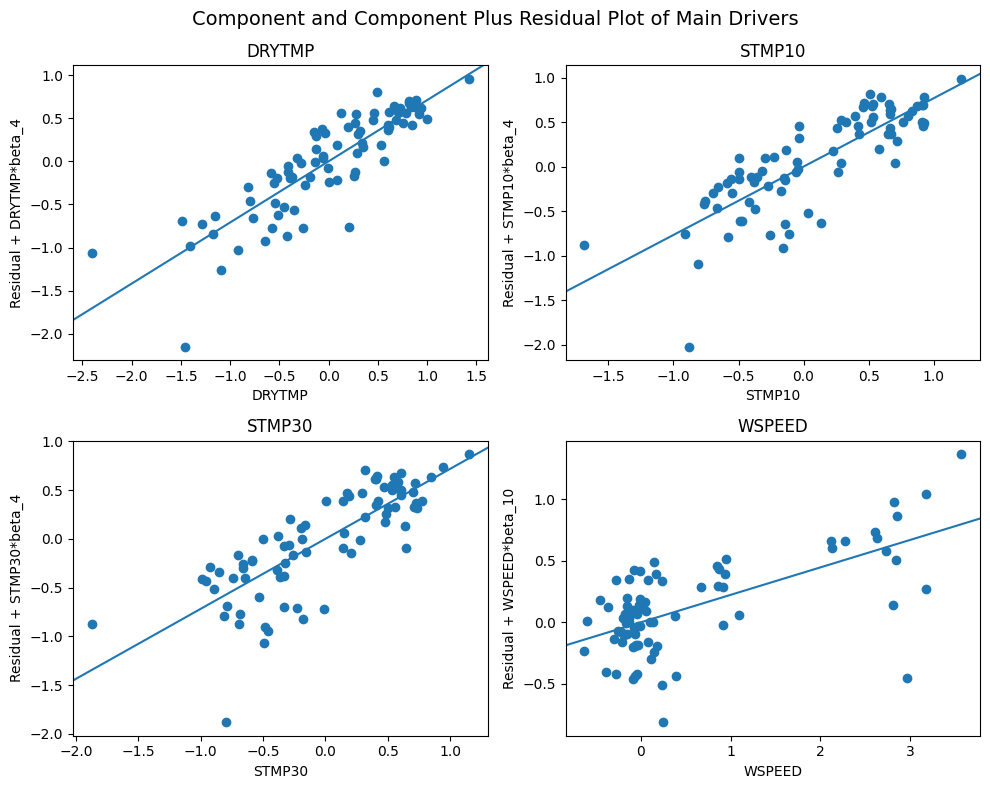

In [27]:
# plotting main drivers using component and component plus residual plot
import statsmodels.api as sm

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 8))

sm.graphics.plot_ccpr(model_1, "DRYTMP", ax = axs[0, 0])
axs[0, 0].set_title("DRYTMP")

sm.graphics.plot_ccpr(model_5, "STMP10", ax = axs[0, 1])
axs[0, 1].set_title("STMP10")

sm.graphics.plot_ccpr(model_4, "STMP30", ax = axs[1, 0])
axs[1, 0].set_title("STMP30")

sm.graphics.plot_ccpr(model_6, "WSPEED", ax = axs[1, 1])
axs[1, 1].set_title("WSPEED")

plt.suptitle("Component and Component Plus Residual Plot of Main Drivers", fontsize = 14)
plt.tight_layout()
plt.show()

## Cluster 1

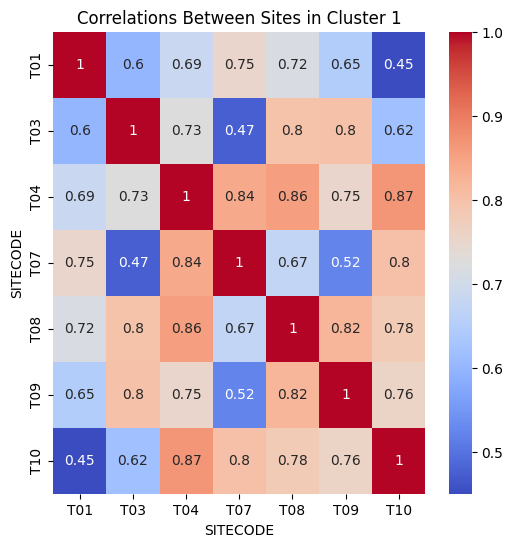

In [28]:
# extracting SITECODEs and their moth counts for each year
cluster_1 = site_correlation[site_correlation["CLUSTER"] == 1].index.values
cluster_1 = site_moth_mean.loc[:, cluster_1]
corr_cluster1 = cluster_1.corr(method = "spearman")

# plotting heatmap
plt.figure(figsize = (6, 6))
sns.heatmap(corr_cluster1, cmap = "coolwarm", annot = True)
plt.title("Correlations Between Sites in Cluster 1")
plt.show()

### Preparing Data for Regression

In [29]:
sites = ['T01', 'T03', 'T04', 'T07', 'T08', 'T09', 'T10']

# aggregating moth data for cluster 1
unique_samples = df[["SITECODE", "YEAR", "LCODE", "SAMPLE_DATE", "VALUE"]].drop_duplicates()
moth_cluster1 = unique_samples[unique_samples["SITECODE"].isin(sites)]
moth_cluster1 = moth_cluster1.groupby(["YEAR", "SITECODE"])["VALUE"].mean().reset_index().sort_values(by = ["SITECODE", "YEAR"])
moth_cluster1.reset_index(drop = True, inplace = True)
moth_cluster1

# aggregating weather data
weather_vars = ['SITECODE', 'YEAR', 'DRYTMP', 'NETRAD', 'SOLAR', 'STMP10', 'STMP30', 'SURWET', 'WSPEED', 'RAIN'] # plus year
weather_cluster1 = df[df["SITECODE"].isin(sites)]
weather_cluster1 = weather_cluster1.loc[:, weather_vars]
weather_cluster1 = weather_cluster1.groupby(["SITECODE", "YEAR"]).agg(
    {
    "DRYTMP": "mean",
    "NETRAD": "mean",
    "SOLAR": "mean",
    "STMP10": "mean",
    "STMP30": "mean",
    "SURWET": "mean",
    "WSPEED": "mean",
    "RAIN": "sum"
}).reset_index()

# merging weather and moth data
cluster1_regression = pd.merge(moth_cluster1, weather_cluster1, on = ["SITECODE", "YEAR"], how = "inner")

# using log to standardize VALUE
cluster1_regression["LOG_VALUE"] = np.log(cluster1_regression["VALUE"])

# reordering the column order to bring LOG_VALUE next to the VALUE
cluster1_regression = cluster1_regression.loc[:, ["YEAR", "SITECODE", "VALUE", "LOG_VALUE", "DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]]

# applying robust scaling to weather variables
robust_scaler = RobustScaler()
cols = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]
for col in cols:
  robust_scaler = RobustScaler()
  cluster1_regression[col] = robust_scaler.fit_transform(cluster1_regression[[col]])

cluster1_regression



,YEAR,SITECODE,VALUE,LOG_VALUE,DRYTMP,NETRAD,SOLAR,STMP10,STMP30,SURWET,WSPEED,RAIN
0,1993,T01,1.808950,0.592747,-0.115773,0.254787,-0.074029,0.104305,0.012744,-0.377229,-0.157226,0.005705
1,1994,T01,2.169628,0.774556,0.363927,0.819727,0.296070,0.588872,0.315039,-0.338468,-0.160117,0.102225
2,1995,T01,3.074753,1.123225,0.662184,1.224815,0.740560,0.696535,0.360118,-0.284109,-0.134219,-0.449629
3,1996,T01,3.646707,1.293824,0.311404,0.660515,0.416740,0.524190,0.360063,-0.214710,-0.281438,-0.271991
4,1997,T01,2.729730,1.004203,0.260273,0.411355,0.006681,0.308591,0.158898,-0.129683,-0.266043,0.420650
...,...,...,...,...,...,...,...,...,...,...,...,...
136,2011,T10,4.222222,1.440362,0.186378,-0.104836,0.683207,0.078668,0.073330,-0.921658,0.434258,-0.159971
137,2012,T10,4.202020,1.435565,0.340781,-0.258479,0.497306,0.226313,0.254009,-0.922584,0.335468,0.632744
138,2013,T10,4.991304,1.607697,0.632659,0.501421,1.129157,0.363353,0.307712,-0.922755,0.306261,0.003195
139,2014,T10,4.952719,1.599937,0.344874,0.513997,1.194105,0.339566,0.345866,-0.921527,0.236877,1.617684


### Regression for Cluster 1

#### Correlation Heatmap of Weather Variables for Cluster 1

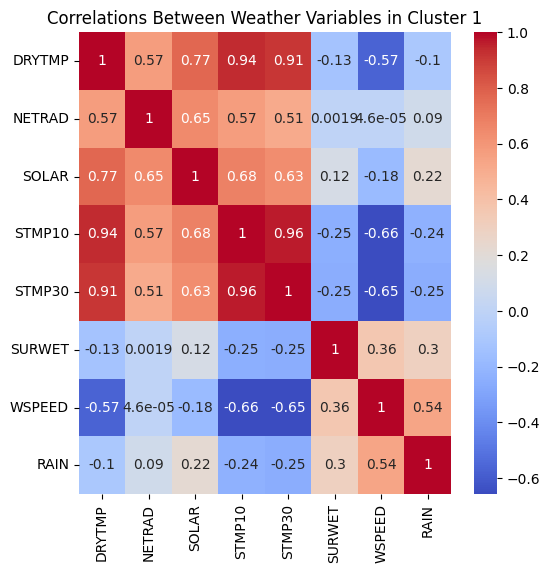

In [30]:
# checking for correlation between weather variables
weather_vars = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]

# calculating the correlation matrix
weather_corr = cluster1_regression[weather_vars].corr()

## plotting heatmap
plt.figure(figsize = (6, 6))
sns.heatmap(weather_corr, cmap = "coolwarm", annot = True)
plt.title("Correlations Between Weather Variables in Cluster 1")
plt.show()

# THRESHOLD: 0.6
# DRYTMP = correlates with SOLAR, STMP10, STMP30
# NETRAD = correlates with SOLAR
# SOLAR = correlates with DRYTMP, NETRAD, STMP10, STMP30
# STMP10 = correlates with DRYTMP, SOLAR, STMP30
# STMP30 = correlates with DRYTMP, SOLAR, STMP10


#### Regression 1: DRYTMP, NETRAD, SURWET, WSPEED, RAIN

In [31]:
# defining formula
formula_1 = "LOG_VALUE ~ DRYTMP + NETRAD + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_1 = smf.ols(formula = formula_1, data = cluster1_regression).fit()

# printing results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     34.32
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           4.26e-33
Time:                        14:07:37   Log-Likelihood:                -33.118
No. Observations:                 141   AIC:                             90.24
Df Residuals:                     129   BIC:                             125.6
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.6543      0

In [32]:
# conclusions:

# R-squred: 0.745 - model explains 74.5% of the variation in moth counts; good fit

# DRYTMP (Dry bulb temperature - average): coeff = 0.8526, P>|t| = 0.000 - the strongest positive driver; warm years significantly contribute to higher moth counts
# WSPEED (Wind speed - average): coeff = -0.6649 , P>|t| = 0.000 - the strongest negative driver; windy years negatively affect moth populations

# NETRAD (Net radiation - average): coeff = -0.0669; P>|t| = 0.154 - net radiation not a significant driver (DRYTMP dominates)
# SURWET (Surface wetness - number of minutes in the hour that surface is wet): coeff =  0.1311, P>|t| = 0.008 - positive driver; surface wetness contributes to higher moth counts
# RAIN (Rainfall - total): coeff = 0.1612, P>|t| = 0.000 - positive driver; like SURWET, years with higher precipitation contribute to higher moth counts

# T04, T07, T10  = more moth counts than T01 (positive coeff)
# T03 = very similar moth counts as T01 (coeff almost 0)
# T08, T09 = less moth counts than T01 (negative coeff)

#### Regression 2: STMP10, NETRAD, SURWET, WSPEED, RAIN

In [33]:
# defining formula
formula_2 = "LOG_VALUE ~ STMP10 + NETRAD + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_2 = smf.ols(formula = formula_2, data = cluster1_regression).fit()

# printing results
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     32.76
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           3.71e-32
Time:                        14:07:37   Log-Likelihood:                -35.543
No. Observations:                 141   AIC:                             95.09
Df Residuals:                     129   BIC:                             130.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.6090      0

In [34]:
# conclusions:

# R-squred: 0.736 - model explains 73.6% of the variation in moth counts; good fit

# STMP10 (Soil temperature at 10 cm - average): coeff = 1.0229, P>|t| = 0.000 - the strongest positive driver; high soil temperature at 10cm massively increases moth counts (even more than DRYTMP)
# WSPEED (Wind speed - average): coeff = -0.5022 , P>|t| = 0.004 - the strongest negative driver; wind remains the strongest negative driver

# SURWET (Surface wetness - number of minutes in the hour that surface is wet): coeff =  0.2114 , P>|t| = 0.008 - positive driver; surface wetness contributes to higher moth counts; bigger effect than in model 1
# RAIN (Rainfall - total): coeff = 0.1887, P>|t| = 0.000 - positive driver; pretty consistent with previous model

#### Regression 3: STMP30, NETRAD, SURWET, WSPEED, RAIN



In [35]:
# defining formula
formula_3 = "LOG_VALUE ~ STMP30 + NETRAD + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_3 = smf.ols(formula = formula_3, data = cluster1_regression).fit()

# printing results
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     30.56
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           9.07e-31
Time:                        14:07:38   Log-Likelihood:                -39.127
No. Observations:                 141   AIC:                             102.3
Df Residuals:                     129   BIC:                             137.6
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.7500      0

In [36]:
# conclusions:

# R-squred: 0.723 - model explains 72.3% of the variation in moth counts; good fit

# STMP30 (Soil temperature at 30 cm - average): coeff = 0.8755, P>|t| = 0.000 - the strongest positive driver; not as significant as STMP10
# WSPEED (Wind speed - average): coeff = -0.5037 , P>|t| = 0.005 - the strongest negative driver; wind remains the strongest negative driver

# SURWET (Surface wetness - number of minutes in the hour that surface is wet): coeff =  0.1869 , P>|t| = 0.005 - positive driver; surface wetness contributes to higher moth counts
# RAIN (Rainfall - total): coeff = 0.1942, P>|t| = 0.000 - positive driver; pretty consistent with previous model; this time highest coefficient from all models

#### Regression 4: SOLAR, SURWET, WPSEED, RAIN

In [37]:
# defining formula
formula_4 = "LOG_VALUE ~ SOLAR + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_4 = smf.ols(formula = formula_4, data = cluster1_regression).fit()

# printing results
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     26.28
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           1.10e-26
Time:                        14:07:38   Log-Likelihood:                -51.592
No. Observations:                 141   AIC:                             125.2
Df Residuals:                     130   BIC:                             157.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.7669      0

In [38]:
# conclusions:

# R-squared: 0.669 - model explains 66.9% of variation in the moth counts; worst one so far

# SOLAR (Solar Radiation - average): coeff 0.3527, P>|t| = 0.000 - the strongest positive driver in this model; not as signficant as STMP10, STMP30, or DRYTMP
# WSPEED: coeff = -0.7703, P>|t| = 0.000 - the strongest negative driver in this model; the largest negative coefficient for WSPEED from all models

#### Regression 5: DRYTMP, NETRAD, STMP30, SURWET, WSPEED, RAIN

In [39]:
# defining formula
formula_5 = "LOG_VALUE ~ DRYTMP + NETRAD + STMP30 + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_5 = smf.ols(formula = formula_5, data = cluster1_regression).fit()

# printing results
print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     33.35
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           1.15e-33
Time:                        14:07:38   Log-Likelihood:                -29.614
No. Observations:                 141   AIC:                             85.23
Df Residuals:                     128   BIC:                             123.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.6876      0

In [40]:
# conclusions:

# R-squared: 0.758 - this model explains 75.8% variation in moth data

# WSPEED - signifcant negative driver
# DRYTMP and STMP30 - both "warmth" variables with significant positive effect on moth populations !!!!
# SURWET and RAIN low/moderate positive drivers

#### Regression 6: All Variables

In [41]:
# defining formula
formula_6 = "LOG_VALUE ~ DRYTMP + NETRAD + SOLAR + STMP10 + STMP30 + SURWET + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_6 = smf.ols(formula = formula_6, data = cluster1_regression).fit()

# printing results
print(model_6.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     29.08
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           8.37e-33
Time:                        14:07:38   Log-Likelihood:                -27.848
No. Observations:                 141   AIC:                             85.70
Df Residuals:                     126   BIC:                             129.9
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.6714      0

In [42]:
# conclusions

# R-squared: 0.764 - the model explains 76.4% of variation in moth counts; not a bad fit

# WSPEED remained dominant negative driver for the moth abundance
# DRYTMP the highest "temperature" variable - the biggest driver, however, model 2 used weather variable STMP10 which had the highest coefficient
# other temperature variables not as significant as in other models - most likely due to mutlicollinearity between temperature variables

#### LASSO Model + OLS Model

In [43]:
# running a LASSO model to handle mutlicollinearity and then extracting variables which were not assigned coefficient 0 by LASSO
from sklearn.linear_model import LassoCV

# weather vars
weather_vars = ['DRYTMP', 'NETRAD', 'SOLAR', 'STMP10', 'STMP30', 'SURWET', 'WSPEED', 'RAIN']

# determining X and Y
X = cluster1_regression[weather_vars]
Y = cluster1_regression["LOG_VALUE"]

# fitting the model
model = LassoCV(cv = 5).fit(X, Y)

# creating a dictionary from results, adding it to dataframe and selecting only variables that do not have coefficient 0
model = {
    "VARIABLE": weather_vars,
    "COEFF": model.coef_
}
model = pd.DataFrame(model)
model = model[model["COEFF"] != 0].reset_index(drop = True)

model

,VARIABLE,COEFF
0,DRYTMP,0.216962
1,NETRAD,0.050254
2,SOLAR,0.126810
3,WSPEED,0.001064
4,RAIN,0.238895


In [44]:
# defining formula based on selected LASSO variables
formula_final = "LOG_VALUE ~ DRYTMP + NETRAD + SOLAR + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_final = smf.ols(formula = formula_final, data = cluster1_regression).fit()

# printing results
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     32.22
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           8.02e-32
Time:                        14:07:38   Log-Likelihood:                -36.407
No. Observations:                 141   AIC:                             96.81
Df Residuals:                     129   BIC:                             132.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.6544      0

#### Final Conclusion

In [45]:
# temperature variables signficantly and positively correlate  higher moth counts implying that hot years/warm temperature helps drive moth abundance
  # STMP10 having the biggest impact when isolated from other temperature varibles with which it correlates the most
  # NETRAD and SOLAR not significant

# WIND has negative effect on moth abundance, no matter what

# RAIN and SURWET are positive drivers of moth abundance but do not have big coefficients - are not the main drivers, although wetter and more "moisturous" climate helps moth abundance

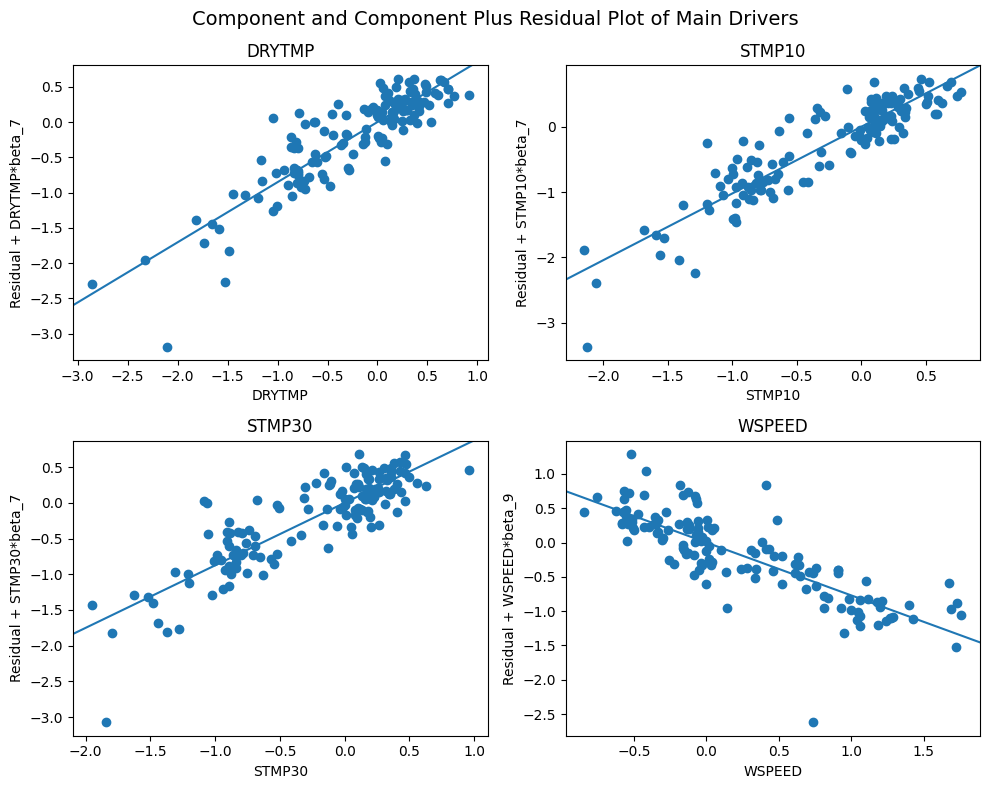

In [46]:
# plotting main drivers using component and component plus residual plot
import statsmodels.api as sm

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 8))

sm.graphics.plot_ccpr(model_1, "DRYTMP", ax = axs[0, 0])
axs[0, 0].set_title("DRYTMP")

sm.graphics.plot_ccpr(model_2, "STMP10", ax = axs[0, 1])
axs[0, 1].set_title("STMP10")

sm.graphics.plot_ccpr(model_3, "STMP30", ax = axs[1, 0])
axs[1, 0].set_title("STMP30")

sm.graphics.plot_ccpr(model_4, "WSPEED", ax = axs[1, 1])
axs[1, 1].set_title("WSPEED")

plt.suptitle("Component and Component Plus Residual Plot of Main Drivers", fontsize = 14)
plt.tight_layout()
plt.show()

## Geographical Data: Plotting SITECODE

In [47]:
# installing folium
!pip install folium

In [48]:
# loading the geographical data about sites - customly created data from our data description file
df_geographic = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/SCC 450 - Group Project/Data/SITE Geographical Data.csv")
df_geographic = df_geographic[df_geographic["CLUSTER_TYPE"] != "Not Analyzed"]
df_geographic

,SITECODE,Name,Lat_Decimal,Lon_Decimal,CLUSTER_TYPE
0,T01,Drayton,52.1939,-1.7644,Negative Wind
1,T02,Glensaugh,56.9093,-2.5534,Positive Wind
2,T03,Hillsborough,54.4534,-6.0781,Negative Wind
3,T04,Moor House,54.6950,-2.3879,Negative Wind
4,T05,North Wyke,50.7819,-3.9178,Positive Wind
5,T06,Rothamsted,51.8034,-0.3727,Positive Wind
6,T07,Sourhope,55.4899,-2.2120,Negative Wind
7,T08,Wytham,51.7814,-1.3361,Negative Wind
8,T09,Alice Holt,51.1546,-0.8632,Negative Wind
9,T10,Porton Down,51.1272,-1.6399,Negative Wind


In [49]:
import folium

# plotting the map of the UK
map = folium.Map(location = [54.5, -2.5], zoom_start = 6)

# adding rows to the map from dataframe using custom created data from data description file
for index, row in df_geographic.iterrows():
  coordinates = [row["Lat_Decimal"], row["Lon_Decimal"]]
  folium.Marker(coordinates).add_to(map)

  # labeling each site with a color
  if row["CLUSTER_TYPE"] == "Positive Wind":
    color = "green"
  else:
    color = "red"

  # showing the labels in the map
  folium.Marker(location = coordinates, popup = f"{row["SITECODE"]}: {row["Name"]}", icon = folium.Icon(color = color)).add_to(map)

# showing the map
map

## Further Regression

### PCA on Cluster 0 Weather Variables

In [50]:
# PCA on cluster 0 weather variables
pca_cluster_0 = cluster0_regression.copy()

# PCA
pca = PCA(n_components = 1)

# isolating temperature variables - DRYTMP, STMP10, STMP30
temp_variables = ["DRYTMP", "STMP10", "STMP30"]
pca_temp = pca_cluster_0[temp_variables]

# transforming temperature variables
pca_temp = pca.fit_transform(pca_temp)
pca_temp = pd.DataFrame(pca_temp, columns = ["TEMPERATURE"])


# isolating radiation variables - NETRAD, SOLAR
solar_variables = ["SOLAR", "NETRAD"]
pca_solar = pca_cluster_0[solar_variables]

# transforming radiation variables
pca_solar = pca.fit_transform(pca_solar)
pca_solar = pd.DataFrame(pca_solar, columns = ["SOLAR_RADIATION"])


# isolating RAIN and SURWET variables
wet_variables = ["SURWET", "RAIN"]
pca_wet = pca_cluster_0[wet_variables]

# transforming RAIN and SURWET variables
pca_wet = pca.fit_transform(pca_wet)
pca_wet = pd.DataFrame(pca_wet, columns = ["MOISTURE"])


# adding each component to the original dataframe
pcas = [pca_temp, pca_solar, pca_wet]

for pca in pcas:
  pca_cluster_0 = pca_cluster_0.join(pca, how = "inner")

pca_cluster_0


,YEAR,SITECODE,VALUE,LOG_VALUE,DRYTMP,NETRAD,SOLAR,STMP10,STMP30,SURWET,WSPEED,RAIN,TEMPERATURE,SOLAR_RADIATION,MOISTURE
0,1994,T02,2.774194,1.020360,-0.152413,-1.156325,-0.612662,-0.038328,-0.287483,0.954761,-0.270010,-1.325585,-0.295011,-1.247884,-1.776844
1,1995,T02,2.221095,0.798000,-0.055773,-1.576616,-0.046034,-0.052869,-0.331030,0.988002,-0.156176,-0.883554,-0.264215,-1.121446,-1.357966
2,1996,T02,2.033465,0.709741,-0.376439,-0.584912,-0.378508,-0.152664,-0.384865,-0.346010,-0.174655,-0.051211,-0.553804,-0.686438,-0.212498
3,1997,T02,1.264484,0.234664,-0.349493,-0.538919,-0.228078,0.033384,-0.331539,-0.287780,-0.390576,-0.480008,-0.407018,-0.545186,-0.641944
4,1998,T02,0.903315,-0.101684,-0.646631,-1.111170,-1.105548,-0.160432,-0.490579,0.556685,-0.084814,-0.243782,-0.789236,-1.576854,-0.629248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2011,T12,5.937984,1.781370,-1.282075,-1.034900,-0.610625,-0.756848,-0.993784,-0.229687,2.608645,3.390745,-1.793264,-1.163415,3.085577
76,2012,T12,4.230769,1.442384,-2.404040,-1.916707,-1.637726,-1.684876,-1.873220,-0.020821,3.565373,-0.322400,-3.493542,-2.515871,-0.557751
77,2013,T12,4.235955,1.443609,-0.917719,-0.765841,-0.047185,-0.581345,-0.816146,-0.073065,3.178688,0.711100,-1.367589,-0.568204,0.454813
78,2014,T12,5.201754,1.648996,-1.151866,-0.603821,-0.121392,-0.693562,-0.924321,-0.029424,2.129172,1.720157,-1.637597,-0.511654,1.419252


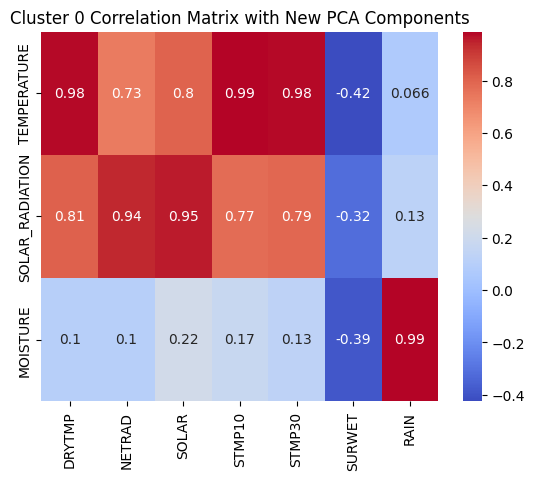

In [51]:
# creating a correlation heatmap to see how new pca components correlate with each individual weather variable
pca_components = ["TEMPERATURE", "SOLAR_RADIATION", "MOISTURE"]
orig_varibales = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "RAIN"]
pca_corr_0 = pca_cluster_0[pca_components + orig_varibales].corr()
pca_corr_0 = pca_corr_0.loc[pca_components, orig_varibales]

sns.heatmap(pca_corr_0, annot = True, cmap = "coolwarm")
plt.title("Cluster 0 Correlation Matrix with New PCA Components")
plt.show()

In [52]:
# OLS regression

# defining formula
formula_pca_1 = "LOG_VALUE ~ TEMPERATURE + SOLAR_RADIATION + MOISTURE + WSPEED + C(SITECODE)"

# fitting the model
model_pca_1 = smf.ols(formula = formula_pca_1, data = pca_cluster_0).fit()

# printing results
print(model_pca_1.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.561
Method:                 Least Squares   F-statistic:                     15.39
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           3.81e-12
Time:                        14:07:46   Log-Likelihood:                -19.318
No. Observations:                  80   AIC:                             54.64
Df Residuals:                      72   BIC:                             73.69
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9433      0

In [53]:
# PCA on cluster 0 weather variables - without MOISTURE component
pca_cluster_0 = cluster0_regression.copy()

# PCA
pca = PCA(n_components = 1)

# isolating temperature variables - DRYTMP, STMP10, STMP30
temp_variables = ["DRYTMP", "STMP10", "STMP30"]
pca_temp = pca_cluster_0[temp_variables]

# transforming temperature variables
pca_temp = pca.fit_transform(pca_temp)
pca_temp = pd.DataFrame(pca_temp, columns = ["TEMPERATURE"])


# isolating radiation variables - NETRAD, SOLAR
solar_variables = ["SOLAR", "NETRAD"]
pca_solar = pca_cluster_0[solar_variables]

# transforming radiation variables
pca_solar = pca.fit_transform(pca_solar)
pca_solar = pd.DataFrame(pca_solar, columns = ["SOLAR_RADIATION"])

# adding each component to the original dataframe
pcas = [pca_temp, pca_solar]

for pca in pcas:
  pca_cluster_0 = pca_cluster_0.join(pca, how = "inner")

pca_cluster_0

,YEAR,SITECODE,VALUE,LOG_VALUE,DRYTMP,NETRAD,SOLAR,STMP10,STMP30,SURWET,WSPEED,RAIN,TEMPERATURE,SOLAR_RADIATION
0,1994,T02,2.774194,1.020360,-0.152413,-1.156325,-0.612662,-0.038328,-0.287483,0.954761,-0.270010,-1.325585,-0.295011,-1.247884
1,1995,T02,2.221095,0.798000,-0.055773,-1.576616,-0.046034,-0.052869,-0.331030,0.988002,-0.156176,-0.883554,-0.264215,-1.121446
2,1996,T02,2.033465,0.709741,-0.376439,-0.584912,-0.378508,-0.152664,-0.384865,-0.346010,-0.174655,-0.051211,-0.553804,-0.686438
3,1997,T02,1.264484,0.234664,-0.349493,-0.538919,-0.228078,0.033384,-0.331539,-0.287780,-0.390576,-0.480008,-0.407018,-0.545186
4,1998,T02,0.903315,-0.101684,-0.646631,-1.111170,-1.105548,-0.160432,-0.490579,0.556685,-0.084814,-0.243782,-0.789236,-1.576854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2011,T12,5.937984,1.781370,-1.282075,-1.034900,-0.610625,-0.756848,-0.993784,-0.229687,2.608645,3.390745,-1.793264,-1.163415
76,2012,T12,4.230769,1.442384,-2.404040,-1.916707,-1.637726,-1.684876,-1.873220,-0.020821,3.565373,-0.322400,-3.493542,-2.515871
77,2013,T12,4.235955,1.443609,-0.917719,-0.765841,-0.047185,-0.581345,-0.816146,-0.073065,3.178688,0.711100,-1.367589,-0.568204
78,2014,T12,5.201754,1.648996,-1.151866,-0.603821,-0.121392,-0.693562,-0.924321,-0.029424,2.129172,1.720157,-1.637597,-0.511654


In [54]:
# OLS regression

# defining formula
formula_pca_1 = "LOG_VALUE ~ TEMPERATURE + SOLAR_RADIATION + WSPEED + RAIN + C(SITECODE)"

# fitting the model
model_pca_1 = smf.ols(formula = formula_pca_1, data = pca_cluster_0).fit()

# printing results
print(model_pca_1.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     15.07
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           5.86e-12
Time:                        14:07:46   Log-Likelihood:                -19.821
No. Observations:                  80   AIC:                             55.64
Df Residuals:                      72   BIC:                             74.70
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9075      0

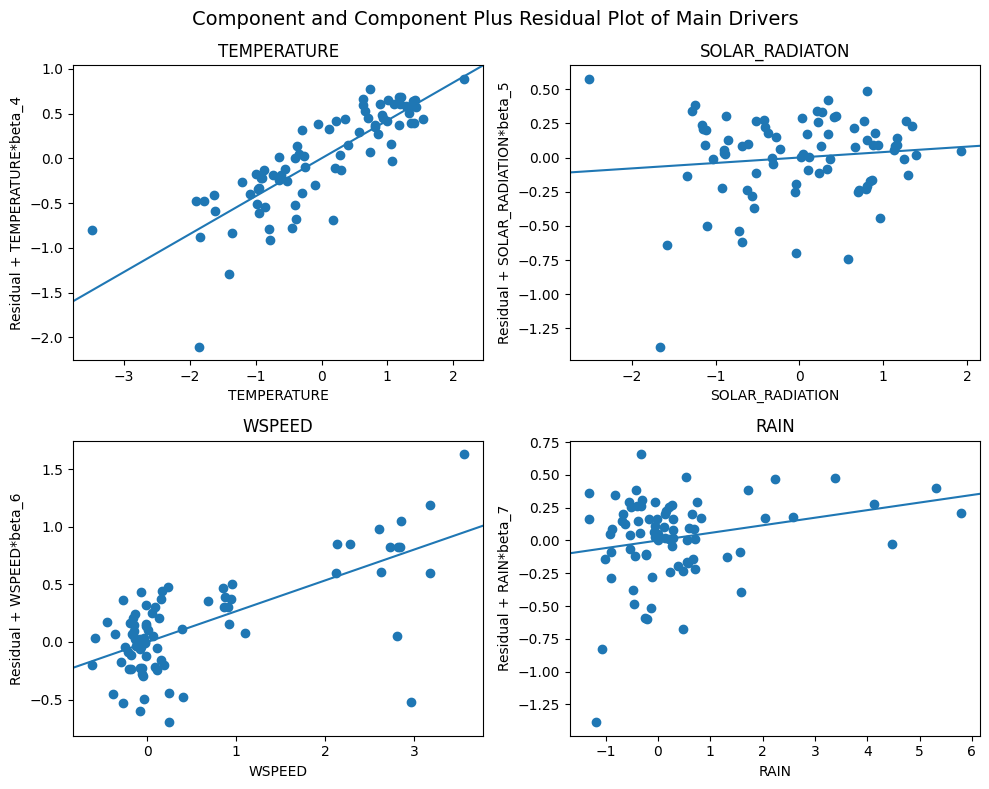

In [55]:
# plotting component and component plus residual plot of main drivers
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 8))

sm.graphics.plot_ccpr(model_pca_1, "TEMPERATURE", ax = axs[0, 0])
axs[0, 0].set_title("TEMPERATURE")

sm.graphics.plot_ccpr(model_pca_1, "SOLAR_RADIATION", ax = axs[0, 1])
axs[0, 1].set_title("SOLAR_RADIATON")

sm.graphics.plot_ccpr(model_pca_1, "WSPEED", ax = axs[1, 0])
axs[1, 0].set_title("WSPEED")

sm.graphics.plot_ccpr(model_pca_1, "RAIN", ax = axs[1, 1])
axs[1, 1].set_title("RAIN")

plt.suptitle("Component and Component Plus Residual Plot of Main Drivers", fontsize = 14)
plt.tight_layout()
plt.show()

### PCA on Cluster 1 Weather Variables

In [56]:
# PCA on cluster 1 weather variables
pca_cluster_1 = cluster1_regression.copy()

# PCA
pca = PCA(n_components = 1)

# isolating temperature variables - DRYTMP, STMP10, STMP30
temp_variables = ["DRYTMP", "STMP10", "STMP30"]
pca_temp = pca_cluster_1[temp_variables]

# transforming temperature variables
pca_temp = pca.fit_transform(pca_temp)
pca_temp = pd.DataFrame(pca_temp, columns = ["TEMPERATURE"])


# isolating radiation variables - NETRAD, SOLAR
solar_variables = ["SOLAR", "NETRAD"]
pca_solar = pca_cluster_1[solar_variables]

# transforming radiation variables
pca_solar = pca.fit_transform(pca_solar)
pca_solar = pd.DataFrame(pca_solar, columns = ["SOLAR_RADIATION"])


# isolating RAIN and SURWET variables
wet_variables = ["SURWET", "RAIN"]
pca_wet = pca_cluster_1[wet_variables]

# transforming RAIN and SURWET variables
pca_wet = pca.fit_transform(pca_wet)
pca_wet = pd.DataFrame(pca_wet, columns = ["MOISTURE"])


# adding each component to the original dataframe
pcas = [pca_temp, pca_solar, pca_wet]

for pca in pcas:
  pca_cluster_1 = pca_cluster_1.join(pca, how = "inner")

pca_cluster_1


,YEAR,SITECODE,VALUE,LOG_VALUE,DRYTMP,NETRAD,SOLAR,STMP10,STMP30,SURWET,WSPEED,RAIN,TEMPERATURE,SOLAR_RADIATION,MOISTURE
0,1993,T01,1.808950,0.592747,-0.115773,0.254787,-0.074029,0.104305,0.012744,-0.377229,-0.157226,0.005705,0.443984,0.484493,-0.532175
1,1994,T01,2.169628,0.774556,0.363927,0.819727,0.296070,0.588872,0.315039,-0.338468,-0.160117,0.102225,1.180547,1.143933,-0.428400
2,1995,T01,3.074753,1.123225,0.662184,1.224815,0.740560,0.696535,0.360118,-0.284109,-0.134219,-0.449629,1.448518,1.744971,-0.901814
3,1996,T01,3.646707,1.293824,0.311404,0.660515,0.416740,0.524190,0.360063,-0.214710,-0.281438,-0.271991,1.135538,1.119098,-0.711667
4,1997,T01,2.729730,1.004203,0.260273,0.411355,0.006681,0.308591,0.158898,-0.129683,-0.266043,0.420650,0.870125,0.651606,-0.050885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,2011,T10,4.222222,1.440362,0.186378,-0.104836,0.683207,0.078668,0.073330,-0.921658,0.434258,-0.159971,0.645304,0.775267,-0.917958
137,2012,T10,4.202020,1.435565,0.340781,-0.258479,0.497306,0.226313,0.254009,-0.922584,0.335468,0.632744,0.922791,0.534913,-0.204391
138,2013,T10,4.991304,1.607697,0.632659,0.501421,1.129157,0.363353,0.307712,-0.922755,0.306261,0.003195,1.208635,1.517851,-0.771477
139,2014,T10,4.952719,1.599937,0.344874,0.513997,1.194105,0.339566,0.345866,-0.921527,0.236877,1.617684,1.040902,1.573116,0.683167


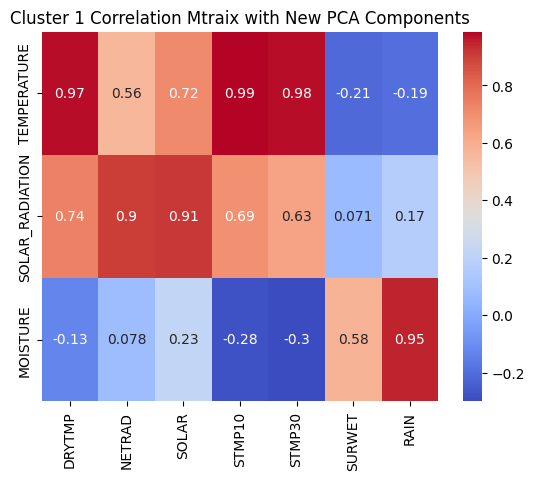

In [57]:
# creating a correlation heatmap to see how new pca components correlate with each individual weather variable
pca_components = ["TEMPERATURE", "SOLAR_RADIATION", "MOISTURE"]
orig_varibales = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "RAIN"]
pca_corr_1 = pca_cluster_1[pca_components + orig_varibales].corr()
pca_corr_1 = pca_corr_1.loc[pca_components, orig_varibales]

sns.heatmap(pca_corr_1, annot = True, cmap = "coolwarm")
plt.title("Cluster 1 Correlation Mtraix with New PCA Components")
plt.show()

In [58]:
# OLS regression

# defining formula
formula_pca_2 = "LOG_VALUE ~ TEMPERATURE + SOLAR_RADIATION + MOISTURE + WSPEED + C(SITECODE)"

# fitting the model
model_pca_2 = smf.ols(formula = formula_pca_2, data = pca_cluster_1).fit()

# printing results
print(model_pca_2.summary())

                            OLS Regression Results                            
Dep. Variable:              LOG_VALUE   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     38.61
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           3.30e-34
Time:                        14:07:47   Log-Likelihood:                -32.335
No. Observations:                 141   AIC:                             86.67
Df Residuals:                     130   BIC:                             119.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.4893      0

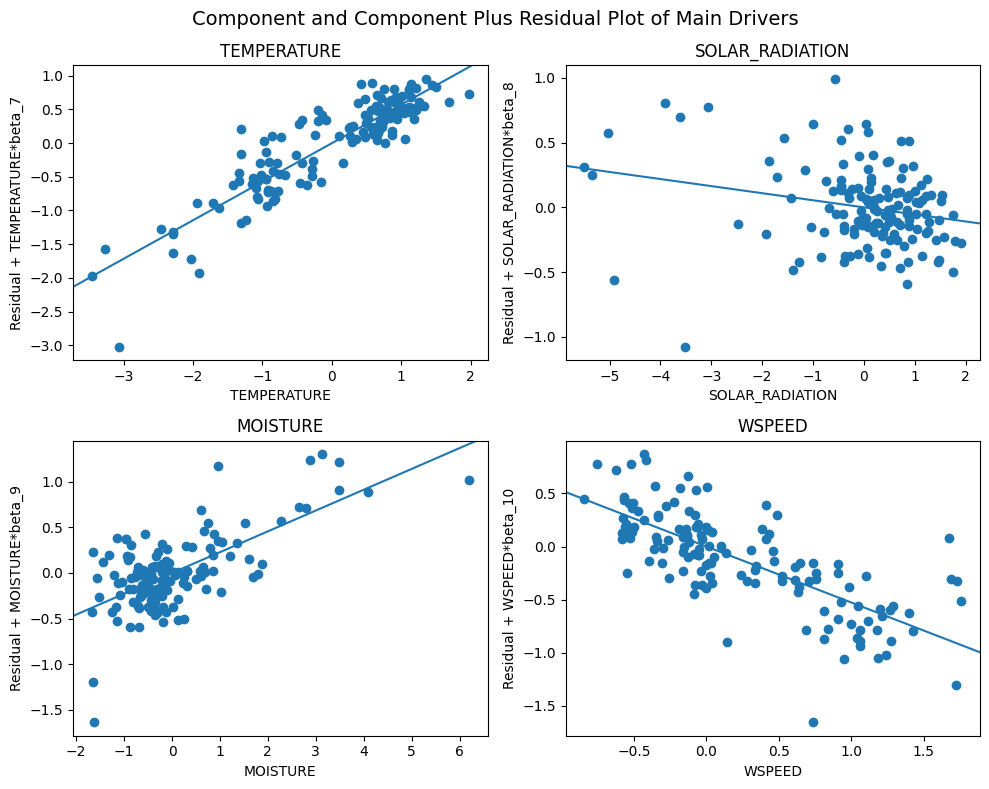

In [59]:
# plotting component and component plus residual plot of main drivers
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 8))

sm.graphics.plot_ccpr(model_pca_2, "TEMPERATURE", ax = axs[0, 0])
axs[0, 0].set_title("TEMPERATURE")

sm.graphics.plot_ccpr(model_pca_2, "SOLAR_RADIATION", ax = axs[0, 1])
axs[0, 1].set_title("SOLAR_RADIATION")

sm.graphics.plot_ccpr(model_pca_2, "MOISTURE", ax = axs[1, 0])
axs[1, 0].set_title("MOISTURE")

sm.graphics.plot_ccpr(model_pca_2, "WSPEED", ax = axs[1, 1])
axs[1, 1].set_title("WSPEED")

plt.suptitle("Component and Component Plus Residual Plot of Main Drivers", fontsize = 14)
plt.tight_layout()
plt.show()